<a href="https://colab.research.google.com/github/nenurd44/ASR-model-comparison/blob/main/comparing_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install -U transformers accelerate datasets soundfile librosa faster-whisper jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 91.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.0/39.0 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 105.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 120.4 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found ex

In [6]:
import pandas as pd
from jiwer import wer, cer
import time
import re

audios = [
    {
        "file": "test_en_1.wav",
        "text": "okay let's go let's start our testing",
        "lang": "en"
    },
    {
        "file": "test_en_2.wav",
        "text": "now im going to the university so i can work on my project",
        "lang": "en"
    },
    {
        "file": "test_en_3.wav",
        "text": "the weather today is sunny and very hot to be honest",
        "lang": "en"
    },
    {
        "file": "test_en_4.wav",
        "text": "im really tired i just wanna go home and sleep",
        "lang": "en"
    },
    {
        "file": "test_en_5.wav",
        "text": "hello what do you think who is the best singer alive",
        "lang": "en"
    },
    {
        "file": "test_en_6.wav",
        "text": "hey siri how to find the purpose of life",
        "lang": "en"
    },
    # ---------- ru
    {
        "file": "test_ru_1.wav",
        "text": "всем привет сегодня у нас погода отличная",
        "lang": "ru"
    },
    {
        "file": "test_ru_2.wav",
        "text": "сегодня у нас наурыз и народа тут очень много",
        "lang": "ru"
    },
    {
        "file": "test_ru_3.wav",
        "text": "когда мы покупали впервые машину там такой приятный запах",
        "lang": "ru"
    },
    {
        "file": "test_ru_4.wav",
        "text": "я люблю гулять ночью потому что ночью обычно тихо на улице",
        "lang": "ru"
    },
    {
        "file": "test_ru_5.wav",
        "text": "привет алиса поставь пожалуйста будильник на семь утра",
        "lang": "ru"
    },
    {
        "file": "test_ru_6.wav",
        "text": "привет а какова вероятность что лифт упадет",
        "lang": "ru"
    },
    # ---------- mix
    {
        "file": "test_mix_1.wav",
        "text": "вчера у нас была презентация i guess it was cringe",
        "lang": "mix"
    },
    {
        "file": "test_mix_2.wav",
        "text": "we planned to go to swimming но там было занято",
        "lang": "mix"
    },
    {
        "file": "test_mix_3.wav",
        "text": "я смотрел the first spider man и мне это очень сильно понравилось",
        "lang": "mix"
    },
    {
        "file": "test_mix_4.wav",
        "text": "hello hello what will be the погода завтра",
        "lang": "mix"
    },
    {
        "file": "test_mix_5.wav",
        "text": "это мне кажется или one plus one is really three",
        "lang": "mix"
    },
    {
        "file": "test_mix_6.wav",
        "text": "с днём рождения тебя i wish you all the best",
        "lang": "mix"
    },
]

results = []

def basic_clean(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return " ".join(text.split())

def record_result(model_name, audio, pred, duration):
    audio["text"] = basic_clean(audio["text"])
    prediction = basic_clean(pred)

    results.append({
        "Model": model_name,
        "File": audio["file"],
        "Language": audio["lang"],
        "Real": audio["text"],
        "Predicted": prediction.strip(),
        "WER": round(wer(audio["text"], prediction), 4),
        "CER": round(cer(audio["text"], prediction), 4),
        "Time_Sec": round(duration, 2)
    })

In [7]:
import torch
from transformers import pipeline

model1 = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-large-v3",
    torch_dtype=torch.float16,
    device="cuda"
)

for audio in audios:
    start = time.time()
    output = model1(audio["file"])
    record_result("Whisper-v3", audio, output["text"], time.time() - start)

del model1
torch.cuda.empty_cache()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]

...

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/340 [00:00<?, ?B/s]

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits pr

In [8]:
from faster_whisper import WhisperModel
import time

model2 = WhisperModel("large-v3", device="cuda", compute_type="float16")

for audio in audios:
    start = time.time()

    segments, info = model2.transcribe(audio["file"], beam_size=1)

    pred = "".join([segment.text for segment in segments])

    record_result("Faster-Whisper-V3", audio, pred, time.time() - start)

del model2
torch.cuda.empty_cache()

In [9]:
import torch
from transformers import pipeline

model3 = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-large-v3-turbo",
    torch_dtype=torch.float16,
    device="cuda"
)

for audio in audios:
    start = time.time()
    result = model3(audio["file"])
    record_result("Whisper-Turbo", audio, result["text"], time.time() - start)

del model3
torch.cuda.empty_cache()

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.62G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/340 [00:00<?, ?B/s]

dalwe rezy

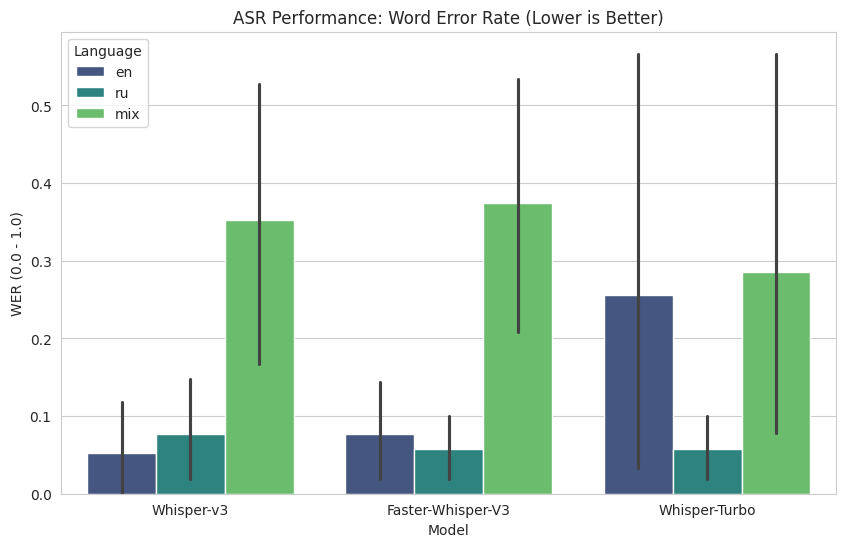

,Model,Language,WER,CER,Time_Sec,Predicted
0,Whisper-Turbo,ru,0.0000,0.0000,0.54,всем привет сегодня у нас погода отличная
1,Whisper-Turbo,en,0.0000,0.0000,0.59,now im going to the university so i can work o...
2,Whisper-Turbo,en,0.0000,0.0000,0.59,the weather today is sunny and very hot to be ...
3,Whisper-Turbo,ru,0.0000,0.0000,0.60,привет а какова вероятность что лифт упадет
4,Whisper-Turbo,ru,0.0000,0.0000,0.63,я люблю гулять ночью потому что ночью обычно т...
5,Whisper-Turbo,mix,0.0000,0.0000,0.64,вчера у нас была презентация i guess it was cr...
6,Whisper-v3,ru,0.0000,0.0000,1.08,всем привет сегодня у нас погода отличная
7,Whisper-v3,en,0.0000,0.0000,1.18,the weather today is sunny and very hot to be ...
8,Whisper-v3,mix,0.0000,0.0000,1.20,это мне кажется или one plus one is really three
9,Faster-Whisper-V3,ru,0.0000,0.0000,1.21,всем привет сегодня у нас погода отличная


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
plot = sns.barplot(data=df, x="Model", y="WER", hue="Language", palette="viridis")
plt.title("ASR Performance: Word Error Rate (Lower is Better)")
plt.ylabel("WER (0.0 - 1.0)")
plt.show()

df_sorted = df.sort_values(by=["WER", "CER", "Time_Sec"], ascending=[True, True, True])

display(df_sorted[["Model", "Language", "WER", "CER", "Time_Sec", "Predicted"]].reset_index(drop=True))

In [18]:
plt.savefig("wer_by_model.png")
plt.savefig("wer_by_language.png")

<Figure size 640x480 with 0 Axes>

In [11]:
import pandas as pd

model_summary = (
    df.groupby("Model")
      .agg({
          "WER": "mean",
          "CER": "mean",
          "Time_Sec": "mean"
      })
      .reset_index()
      .sort_values("WER")
)

print(model_summary)

               Model       WER       CER  Time_Sec
2         Whisper-v3  0.160339  0.104728  1.528333
0  Faster-Whisper-V3  0.170117  0.129594  1.438889
1      Whisper-Turbo  0.199844  0.142556  0.692778


In [12]:
wer_lang = (
    df.groupby(["Model", "Language"])["WER"]
      .mean()
      .reset_index()
)

wer_pivot = wer_lang.pivot(index="Model", columns="Language", values="WER")

print(wer_pivot)

Language                 en       mix        ru
Model                                          
Faster-Whisper-V3  0.077483  0.375000  0.057867
Whisper-Turbo      0.255550  0.286117  0.057867
Whisper-v3         0.051850  0.352783  0.076383


In [13]:
latency = (
    df.groupby("Model")["Time_Sec"]
      .mean()
      .reset_index()
      .sort_values("Time_Sec")
)

print(latency)

               Model  Time_Sec
1      Whisper-Turbo  0.692778
0  Faster-Whisper-V3  1.438889
2         Whisper-v3  1.528333


In [15]:
comparison = (
    df.groupby("Model")["WER"]
      .describe()
)

print(comparison)

                   count      mean       std  min  25%      50%       75%  max
Model                                                                         
Faster-Whisper-V3   18.0  0.170117  0.205497  0.0  0.0  0.11110  0.237500  0.6
Whisper-Turbo       18.0  0.199844  0.291326  0.0  0.0  0.10555  0.191675  1.0
Whisper-v3          18.0  0.160339  0.206827  0.0  0.0  0.11110  0.216650  0.6


In [14]:
hardest = df.sort_values("WER", ascending=False).head(10)

print(hardest[["Model", "Language", "WER", "Predicted"]])

                Model Language     WER  \
40      Whisper-Turbo       en  1.0000   
51      Whisper-Turbo      mix  0.7500   
31  Faster-Whisper-V3      mix  0.6000   
34  Faster-Whisper-V3      mix  0.6000   
17         Whisper-v3      mix  0.6000   
13         Whisper-v3      mix  0.6000   
49      Whisper-Turbo      mix  0.6000   
12         Whisper-v3      mix  0.5000   
30  Faster-Whisper-V3      mix  0.5000   
41      Whisper-Turbo       en  0.3333   

                                           Predicted  
40   привет что вы думаете кто лучший сцентр в жизни  
51             привет привет как будет погода завтра  
31     мы планируем пойти на воду но там было занято  
34  это мне кажется или 1 плюс 1 это действительно 3  
17             с днём рождения тебя а я ищу altebest  
13     мы планируем пойти на воду но там было занято  
49     мы планируем идти на спирт но там было занято  
12     вчера у нас была презентация а я сидел скрынч  
30  вчера у нас была презентация а я здесь

In [17]:
model_summary.to_csv("model_summary.csv", index=False)
wer_pivot.to_csv("wer_by_language.csv")
latency.to_csv("latency.csv", index=False)

trash dalwe

In [1]:
# !pip install jiwer
# from jiwer import wer, cer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 52.4 MB/s eta 0:00:00


In [3]:
# org = "hello my name is baurzhan im from kazakhstan"
# pred = "hello my name is pao zhang im from kazakhstan"
# print(round(wer(org, pred), 4))

0.25


In [1]:
# from nemo.collections.asr.models import EncDecMultiTaskModel

# canary_model = EncDecMultiTaskModel.from_pretrained('nvidia/canary-1b')
# canary_model.to("cuda")

# for audio in audios:
#     start_time = time.time()
#     res = canary_model.transcribe(
#         paths2audio_files=[audio["file"]],
#         task="asr",
#         source_lang=audio["lang"],
#         batch_size=1
#     )

#     prediction = res[0] if isinstance(res, list) else res

#     record_result("Canary-1B", audio, prediction, time.time() - start_time)

# del canary_model
# torch.cuda.empty_cache()
